# **Parcial tres (3) inteligencia artificial UPB**
Facultad de ciencias exactas, escuela de ingenierias
Programas de Ingeniería en Sistemas e Informática – Ingeniería en Ciencia de Datos   

Nombre: Juan David Parra Sierra
NRC: 000475676

#**Unidad de regresion**

A lo largo de este notebook se compraran los algoritmos vistos en clase

- LinearRegression
- Random Forest
- Support Vector Regression (SVR)


In [15]:
# Preliminary steps

# -- Libraries to use

!pip install ucimlrepo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from ucimlrepo import fetch_ucirepo

print("Se han importado las librerias exitosamente.")
print("Versiones principales:")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Sklearn: {sk.__version__}")
print(f"Matplotlib: {mpl.__version__}")

# fetch dataset
concrete_compressive_strength = fetch_ucirepo(id=165)

# data (as pandas dataframes)
feature_data = concrete_compressive_strength.data.features
target_data = concrete_compressive_strength.data.targets

Se han importado las librerias exitosamente.
Versiones principales:
Pandas: 2.2.2
NumPy: 2.0.2
Seaborn: 0.13.2
Sklearn: 1.6.1
Matplotlib: 3.10.0


### **Acción No. 1: Carga y Exploración inicial**

In [16]:
# Initial Data Loading and Exploration

# Print dataset dimensions
print("\n📊 Dimensiones del dataset:")
# Ensure X and y are defined (from previous cell execution)
if 'X' in globals() and 'y' in globals():
    print(f"Dimensiones de las características (X): {X.shape}")
    print(f"Filas: {X.shape[0]}, Columnas: {X.shape[1]}")
    print(f"Dimensiones de la variable objetivo (y): {y.shape}")
    print(f"Filas: {y.shape[0]}, Columnas: {y.shape[1]}")
else:
    print("Las variables X o y no están definidas. Asegúrate de ejecutar la celda de carga de datos primero.")


# Display the first 5 rows of the features DataFrame (X)
print("\nPrimeras 5 filas de las características (X):")
# Check if X is defined before displaying
if 'X' in globals():
    display(X.head())
else:
    print("La variable X no está definida.")


# Display the first 5 rows of the target DataFrame (y)
print("\nPrimeras 5 filas de la variable objetivo (y):")
# Check if y is defined before displaying
if 'y' in globals():
    display(y.head())
else:
    print("La variable y no está definida.")


# Get information about data types and non-null values in X
print("\nInformación sobre las características (X):")
# Check if X is defined before calling info()
if 'X' in globals():
    X.info()
else:
    print("La variable X no está definida.")

# Get information about data types and non-null values in y
print("\nInformación sobre la variable objetivo (y):")
# Check if y is defined before calling info()
if 'y' in globals():
    y.info()
else:
    print("La variable y no está definida.")


# Show data types of features (X)
print("\nTipos de datos de las características (X):")
# Check if X is defined before accessing dtypes
if 'X' in globals():
    print(X.dtypes)
else:
    print("La variable X no está definida.")

# Show data type of the target variable (y)
print("\nTipo de dato de la variable objetivo (y):")
# Check if y is defined before accessing dtypes
if 'y' in globals():
    print(y.dtypes)
else:
    print("La variable y no está definida.")


print("\n\n📈 ESTADÍSTICAS DESCRIPTIVAS")
print("="*50)

# Statistics for numerical variables in X
print("Variables numéricas de X:")
# Check if X is defined before describing
if 'X' in globals():
    print(X.describe())
else:
    print("La variable X no está definida.")

print("\nVariables numéricas de y:")
# Check if y is defined before describing
if 'y' in globals():
    print(y.describe())
else:
    print("La variable y no está definida.")


print("\n\n📈 Número de valores únicos por columna en X:")
# Check if X is defined before calling nunique()
if 'X' in globals():
    print(X.nunique())
else:
    print("La variable X no está definida.")

print("\nNúmero de valores únicos en la variable objetivo (y):")
# Check if y is defined before calling nunique()
if 'y' in globals():
    print(y.nunique())
else:
    print("La variable y no está definida.")


print("\n\n🔎 ANÁLISIS DE VALORES FALTANTES")
print("="*50)

# Check for missing values in X
print("Valores faltantes por columna en X:")
# Check if X is defined before checking for nulls
if 'X' in globals():
    missing_values_X = X.isnull().sum()
    print(missing_values_X)
else:
    print("La variable X no está definida.")


# Check for missing values in y
print("\nValores faltantes por columna en y:")
# Check if y is defined before checking for nulls
if 'y' in globals():
    missing_values_y = y.isnull().sum()
    print(missing_values_y)
else:
    print("La variable y no está definida.")


print("\n\n=== VARIABLE OBJETIVO (Concrete compressive strength) ===")
# Ensure y is a Series or access the column name correctly
# Check if y is defined before proceeding
if 'y' in globals():
    if isinstance(y, pd.DataFrame):
        target_column_name = y.columns[0]
        print(f"Rango de '{target_column_name}': {y[target_column_name].min():.2f} - {y[target_column_name].max():.2f}")
        print(f"Media de '{target_column_name}': {y[target_column_name].mean():.2f}")
        print(f"Mediana de '{target_column_name}': {y[target_column_name].median():.2f}")
        print(f"Desviación estándar de '{target_column_name}': {y[target_column_name].std():.2f}")
    elif isinstance(y, pd.Series):
         print(f"Rango de la variable objetivo: {y.min():.2f} - {y.max():.2f}")
         print(f"Media de la variable objetivo: {y.mean():.2f}")
         print(f"Mediana de la variable objetivo: {y.median():.2f}")
         print(f"Desviación estándar de la variable objetivo: {y.std():.2f}")
    else:
        print("El formato de la variable objetivo (y) no es un DataFrame o Serie de pandas.")
else:
    print("La variable y no está definida.")


📊 Dimensiones del dataset:
Dimensiones de las características (X): (1030, 8)
Filas: 1030, Columnas: 8
Dimensiones de la variable objetivo (y): (1030, 1)
Filas: 1030, Columnas: 1

Primeras 5 filas de las características (X):


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360



Primeras 5 filas de la variable objetivo (y):


,Concrete compressive strength
0,79.99
1,61.89
2,40.27
3,41.05
4,44.30



Información sobre las características (X):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 64.5 KB

Información sobre la variable objetivo (y):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 1 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Concrete compressive strength  10

### **Acción No. 2: Análisis exploratorio de datos (EDA)**

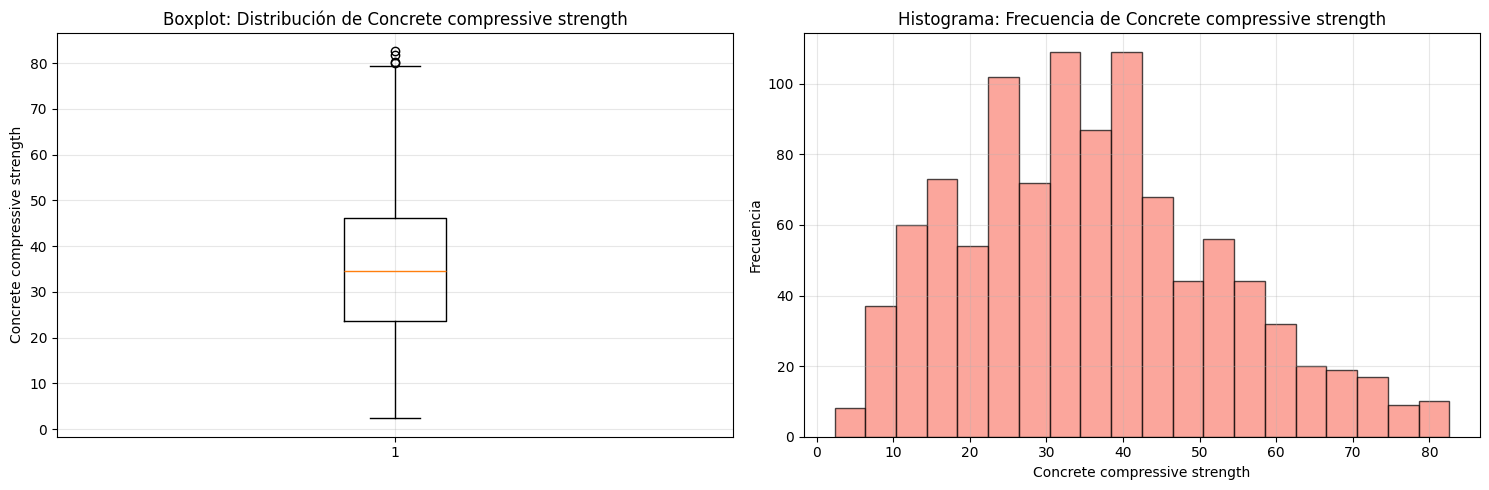

=== MATRIZ DE CORRELACIÓN ===


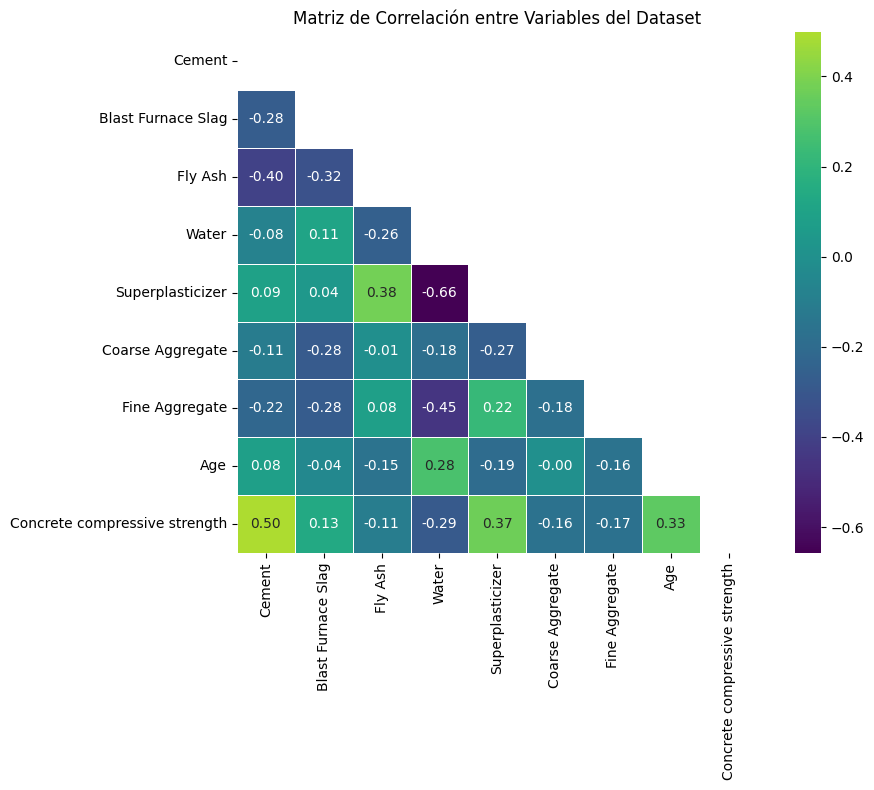

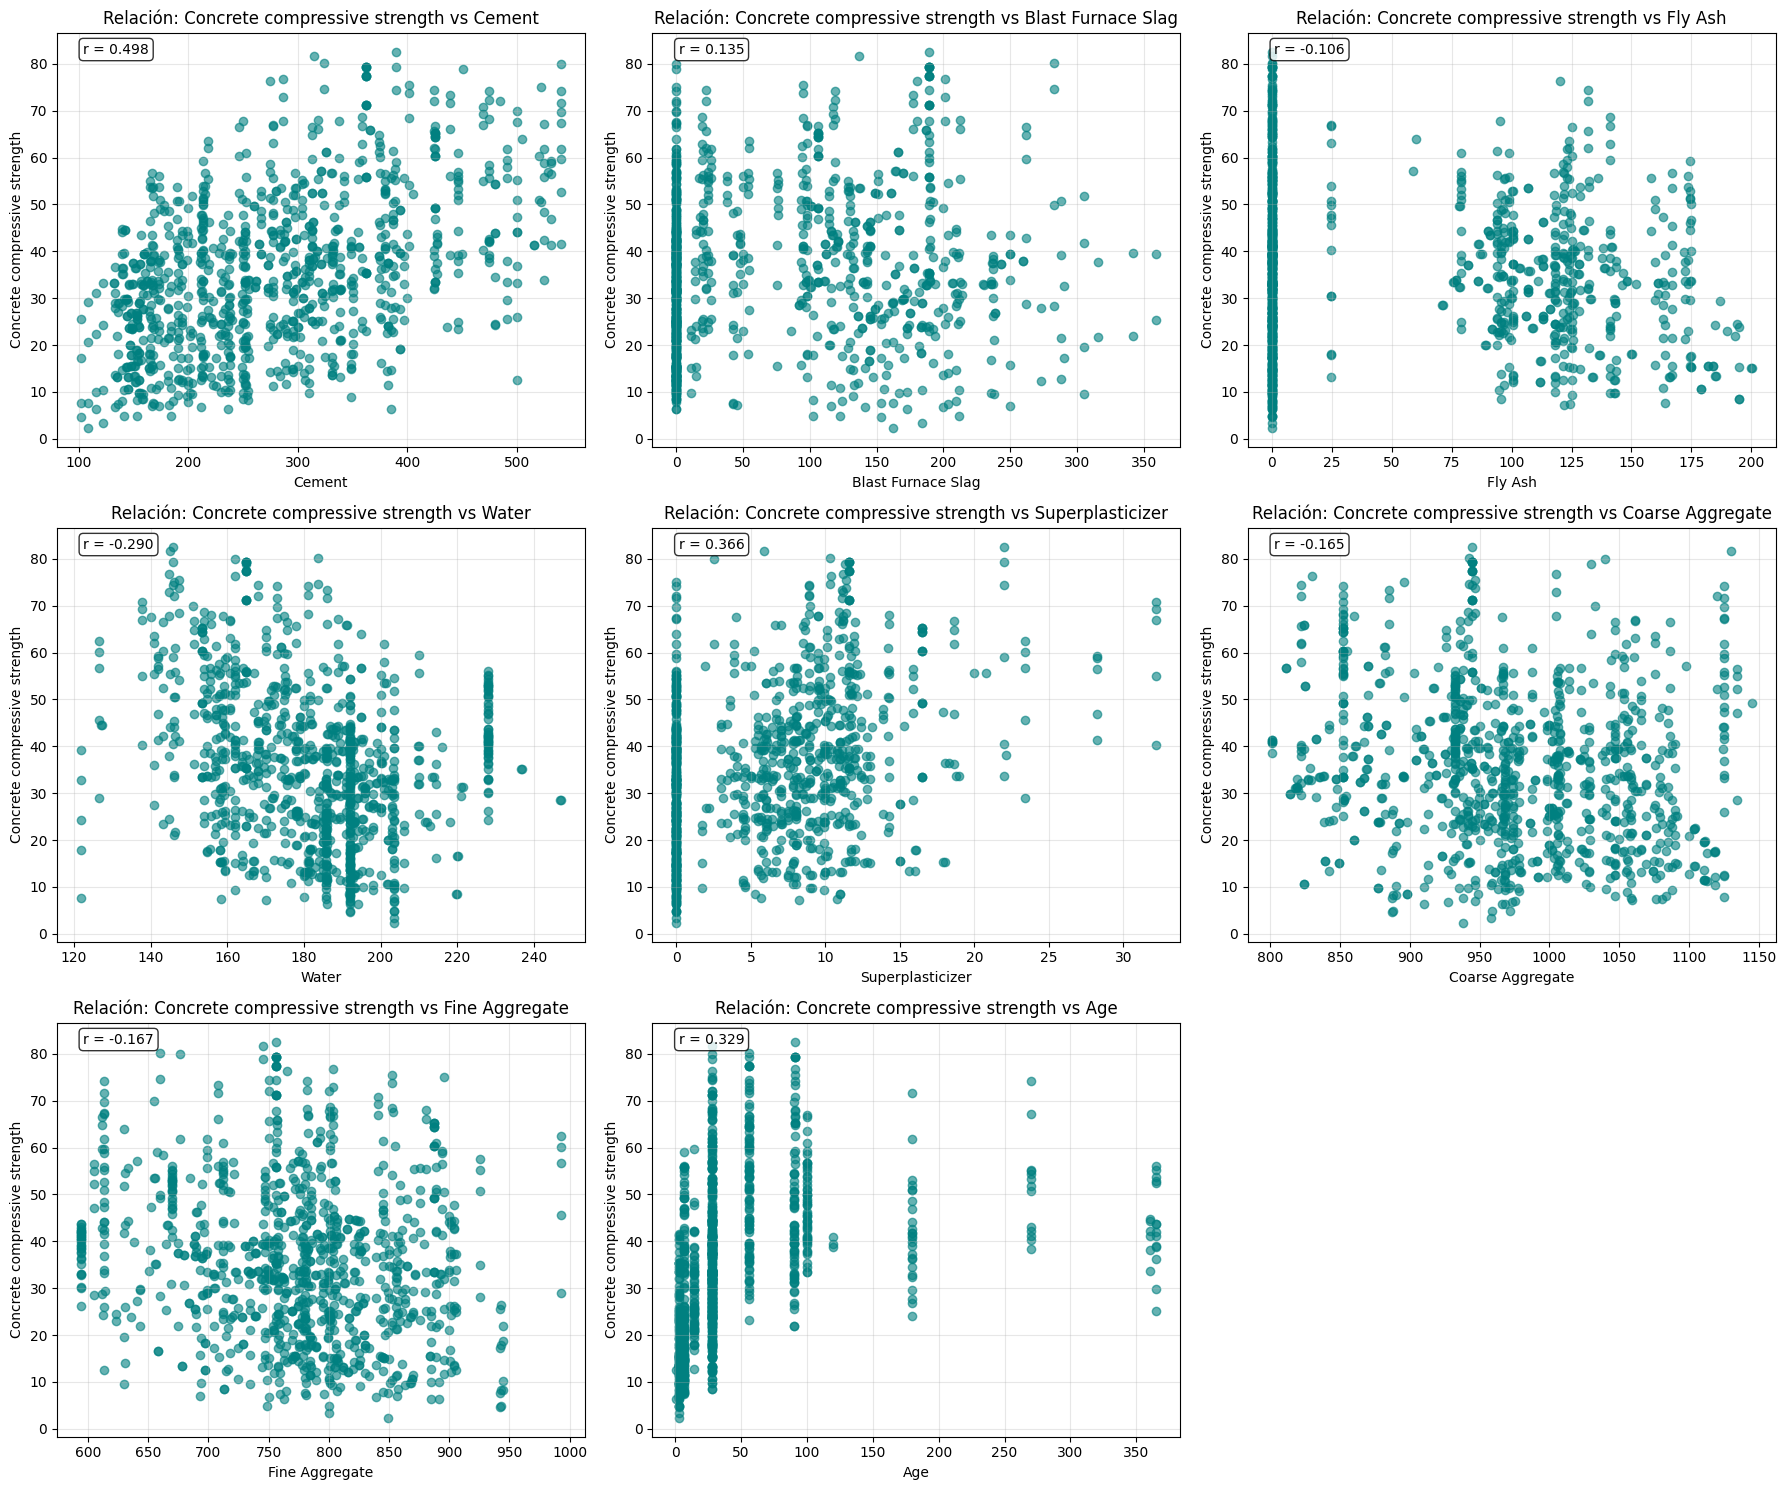

In [17]:
# Action No. 2: Exploratory Data Analysis (EDA)

# Get the name of the target variable column (Concrete compressive strength)
target_column_name = y.columns[0]

# 1. Distribution of the target variable (Concrete compressive strength)
# Changed order: Boxplot first, then Histogram
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot of the target variable (moved to the left)
axes[0].boxplot(y[target_column_name])
axes[0].set_title(f'Boxplot: Distribución de {target_column_name}') # Improved title
axes[0].set_ylabel(target_column_name)
axes[0].grid(True, alpha=0.3)

# Histogram of the target variable (moved to the right)
axes[1].hist(y[target_column_name], bins=20, alpha=0.7, color='salmon', edgecolor='black') # Changed color
axes[1].set_title(f'Histograma: Frecuencia de {target_column_name}') # Improved title
axes[1].set_xlabel(target_column_name)
axes[1].set_ylabel('Frecuencia')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# 2. Correlation matrix

# Combine X and y to calculate correlation between all variables
# Ensure y is a DataFrame if it is not
if isinstance(y, pd.Series):
    combined_df = pd.concat([X, y.to_frame()], axis=1)
else:
    combined_df = pd.concat([X, y], axis=1)

# Correlation matrix of numerical variables
print("=== MATRIZ DE CORRELACIÓN ===")

# Select only numerical columns (although in this dataset all are numerical)
numerical_columns = combined_df.select_dtypes(include=[np.number]).columns
correlation_matrix = combined_df[numerical_columns].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool)) # Mask to show only the lower part
sns.heatmap(correlation_matrix,
            mask=mask,
            annot=True,
            cmap='viridis', # Changed color map
            center=0,
            square=True,
            fmt='.2f',
            linewidths=.5) # Add lines for better separation
plt.title('Matriz de Correlación entre Variables del Dataset') # Improved title
plt.tight_layout()
plt.show()

# 3. Relationships between numerical variables and Concrete compressive strength

# Get the names of the feature columns
numerical_features = X.columns.tolist()
num_features = len(numerical_features)
num_cols = 3 # Number of columns for subplots
num_rows = (num_features + num_cols - 1) // num_cols # Calculate the number of necessary rows

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 5)) # Adjust figure size
axes = axes.flatten() if num_rows > 1 or num_cols > 1 else [axes] # Ensure axes is a flat array

for i, feature in enumerate(numerical_features):
    if i < len(axes):
        axes[i].scatter(X[feature], y[target_column_name], alpha=0.6, color='teal') # Changed scatter plot color
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(target_column_name)
        axes[i].set_title(f'Relación: {target_column_name} vs {feature}') # Improved title
        axes[i].grid(True, alpha=0.3)

        # Calculate correlation between the feature and the target variable
        corr = X[feature].corr(y[target_column_name])
        axes[i].text(0.05, 0.95, f'r = {corr:.3f}',
                    transform=axes[i].transAxes,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Hide empty axes if any
for i in range(len(numerical_features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

### **Acción No. 3: Preprocesamiento de datos**

In [18]:
# Action No. 3: Data Preprocessing

# 1. Create a copy of the datasets for preprocessing
# In our case, we already have X (features) and y (target) separated,
# so we will create copies if we want to modify something without affecting the originals.
processed_features = X.copy()
processed_target = y.copy()

print("Copia de los datasets X y y creada para preprocesamiento.")
print(f"Dimensiones de las características procesadas: {processed_features.shape}")
print(f"Dimensiones de la variable objetivo procesada: {processed_target.shape}")
print()

# 2. Handling missing values
# We already checked in the EDA that there are no missing values,
# but we include the code just in case or for other datasets.
print("\nVerificando valores faltantes en las características procesadas...")
missing_before_features = processed_features.isnull().sum().sum()
print(f"Valores faltantes en las características procesadas antes: {missing_before_features}")

print("\nVerificando valores faltantes en la variable objetivo procesada...")
missing_before_target = processed_target.isnull().sum().sum()
print(f"Valores faltantes en la variable objetivo procesada antes: {missing_before_target}\n")

# In this dataset, there are no missing values, so dropna() will not remove rows.
# If there were, this line would remove them:
# processed_features = processed_features.dropna()
# processed_target = processed_target.dropna() # Note: dropna on processed_target if handling synchronized

missing_after_features = processed_features.isnull().sum().sum()
missing_after_target = processed_target.isnull().sum().sum()

print(f"Valores faltantes en las características procesadas después de (simular) dropna: {missing_after_features}")
print(f"Valores faltantes en la variable objetivo procesada después de (simular) dropna: {missing_after_target}")
print(f"Filas (potencialmente) eliminadas: {len(X) - len(processed_features)}") # Compare with the original X
print()


# 3. Feature selection for the model
# In our case, all columns in processed_features are the features to use.
features_to_use = processed_features.columns.tolist()
print(f"Características seleccionadas (todas las de X): {features_to_use}")
print()

# 4. Separate numerical and categorical variables
# As we already know, all our variables are numerical.
numeric_features = processed_features.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = processed_features.select_dtypes(exclude=[np.number]).columns.tolist() # This will be empty

print(f"Variables numéricas: {numeric_features}")
print(f"Variables categóricas: {categorical_features}") # This will be empty
print()

# At this point, processed_features and processed_target are ready for scaling if necessary.
# Scaling (e.g., with StandardScaler) is common before some models like SVR or Linear Regression
# if feature scales are very different. We will do it later.

# 5. Splitting into training (80%) and test (20%) sets
# We will use the processed data: processed_features and processed_target
X_train, X_test, y_train, y_test = train_test_split(
    processed_features, processed_target,
    test_size=0.2,
    random_state=42,  # For reproducibility
    # stratify=None     # Stratification is not used for continuous target variables (regression)
)

print("=== DIVISIÓN DE DATOS ===")
print(f"Conjunto de entrenamiento - X: {X_train.shape}, y: {y_train.shape}")
print(f"Conjunto de prueba - X: {X_test.shape}, y: {y_test.shape}")
print(f"Porcentaje entrenamiento: {len(X_train)/len(processed_features)*100:.1f}%")
print(f"Porcentaje prueba: {len(X_test)/len(processed_features)*100:.1f}%")
print()

# 6. Feature Scaling
# Fit the scaler only with training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("=== ESCALADO DE CARACTERÍSTICAS ===")
print("Estadísticas del conjunto de entrenamiento escalado:")
print("Media por característica (debe ser ~0):")
print(X_train_scaled.mean().round(4))
print()
print("Desviación estándar por característica (debe ser ~1):")
print(X_train_scaled.std().round(4))
print()

# 7. Preprocessing Summary
print("=== RESUMEN DEL PREPROCESAMIENTO ===")
print(f"✓ Dataset original (X): {X.shape}, (y): {y.shape}") # Reference to the original loaded data
print(f"✓ Dataset procesado (características): {processed_features.shape}, (objetivo): {processed_target.shape}")
print(f"✓ No se encontraron ni eliminaron valores faltantes.") # Based on EDA
print(f"✓ Características seleccionadas (todas las de X): {len(features_to_use)}")
print(f"✓ No se requiere codificación de variables categóricas (ninguna encontrada).")
print(f"✓ Conjuntos entrenamiento/prueba creados (X_train, X_test, y_train, y_test)")
print(f"✓ Escalado aplicado a X_train y X_test (X_train_scaled, X_test_scaled)")
print("\n¡Datos listos para el modelado!")

Copia de los datasets X y y creada para preprocesamiento.
Dimensiones de las características procesadas: (1030, 8)
Dimensiones de la variable objetivo procesada: (1030, 1)


Verificando valores faltantes en las características procesadas...
Valores faltantes en las características procesadas antes: 0

Verificando valores faltantes en la variable objetivo procesada...
Valores faltantes en la variable objetivo procesada antes: 0

Valores faltantes en las características procesadas después de (simular) dropna: 0
Valores faltantes en la variable objetivo procesada después de (simular) dropna: 0
Filas (potencialmente) eliminadas: 0

Características seleccionadas (todas las de X): ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']

Variables numéricas: ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']
Variables categóricas: []

=== DIVISIÓN DE DATOS ===
Conju

### **Acción No. 4: Implementación y Entrenamiento de Modelos**

In [19]:
# Action No. 4: Implementation and Model Training

print("=== ENTRENAMIENTO DE MODELOS DE REGRESIÓN ===")
print()

# Dictionary to store models and results
regression_models = {}
model_predictions = {}
training_durations = {}

import time

# 1. LINEAR REGRESSION
print("1️⃣ ENTRENANDO LINEAR REGRESSION...")
start_time = time.time()

# Create and train the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions
lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)

# Store results
regression_models['Linear Regression'] = lr_model
model_predictions['Linear Regression'] = {
    'train': lr_train_pred,
    'test': lr_test_pred
}
training_durations['Linear Regression'] = time.time() - start_time

print(f"✅ Completado en {training_durations['Linear Regression']:.4f} segundos")
# Show coefficients and intercept (optional but informative)
# Ensure y_train is a DataFrame or Series to access its properties
if isinstance(y_train, pd.DataFrame):
    print(f"   Coeficientes: {len(lr_model.coef_[0])} características") # Access the array inside the array
    print(f"   Intercept: {lr_model.intercept_[0]:.3f}") # Access the element inside the array
else: # If it's a Series
     print(f"   Coeficientes: {len(lr_model.coef_)} características")
     print(f"   Intercept: {lr_model.intercept_:.3f}")

print()

# 2. RANDOM FOREST REGRESSOR
print("2️⃣ ENTRENANDO RANDOM FOREST REGRESSOR...")
start_time = time.time()

# Create and train the model
# Note: Random Forest does not need scaled data, but we use the same for consistency
rf_model = RandomForestRegressor(
    n_estimators=100,       # Number of trees
    max_depth=10,          # Maximum depth
    min_samples_split=5,    # Minimum samples to split
    min_samples_leaf=2,     # Minimum samples at leaf
    random_state=42        # For reproducibility
)
# Ensure y_train is a 1D array for fit if it's a DataFrame with one column
if isinstance(y_train, pd.DataFrame) and y_train.shape[1] == 1:
    rf_model.fit(X_train_scaled, y_train.values.ravel())
else:
    rf_model.fit(X_train_scaled, y_train)


# Make predictions
rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)

# Store results
regression_models['Random Forest'] = rf_model
model_predictions['Random Forest'] = {
    'train': rf_train_pred,
    'test': rf_test_pred
}
training_durations['Random Forest'] = time.time() - start_time

print(f"✅ Completado en {training_durations['Random Forest']:.4f} segundos")
print(f"   Número de árboles: {rf_model.n_estimators}")
print()

# 3. SUPPORT VECTOR REGRESSION (SVR)
print("3️⃣ ENTRENANDO SUPPORT VECTOR REGRESSION...")
start_time = time.time()

# Create and train the model
# Ensure y_train is a 1D array for fit if it's a DataFrame with one column
if isinstance(y_train, pd.DataFrame) and y_train.shape[1] == 1:
    # SVR expects a 1D array for y
    svr_model = SVR(
        kernel='rbf',          # Radial (Gaussian) kernel
        C=100,                 # Regularization parameter
        gamma='scale',         # Kernel parameter
        epsilon=0.1           # Tolerance
    )
    svr_model.fit(X_train_scaled, y_train.values.ravel())
else:
     svr_model = SVR(
        kernel='rbf',          # Radial (Gaussian) kernel
        C=100,                 # Regularization parameter
        gamma='scale',         # Kernel parameter
        epsilon=0.1           # Tolerance
    )
     svr_model.fit(X_train_scaled, y_train)

# Make predictions
svr_train_pred = svr_model.predict(X_train_scaled)
svr_test_pred = svr_model.predict(X_test_scaled)

# Store results
regression_models['SVR'] = svr_model
model_predictions['SVR'] = {
    'train': svr_train_pred,
    'test': svr_test_pred
}
training_durations['SVR'] = time.time() - start_time

print(f"✅ Completado en {training_durations['SVR']:.4f} segundos")
print(f"   Kernel: {svr_model.kernel}")
print(f"   Support vectors: {len(svr_model.support_vectors_)}") # Corrected to support_vectors_
print()

print()
print("🎯 Todos los modelos entrenados exitosamente!")
print("📊 Listos para evaluación y comparación detallada.")

=== ENTRENAMIENTO DE MODELOS DE REGRESIÓN ===

1️⃣ ENTRENANDO LINEAR REGRESSION...
✅ Completado en 0.0151 segundos
   Coeficientes: 8 características
   Intercept: 35.858

2️⃣ ENTRENANDO RANDOM FOREST REGRESSOR...
✅ Completado en 1.4552 segundos
   Número de árboles: 100

3️⃣ ENTRENANDO SUPPORT VECTOR REGRESSION...
✅ Completado en 1.4503 segundos
   Kernel: rbf
   Support vectors: 785


🎯 Todos los modelos entrenados exitosamente!
📊 Listos para evaluación y comparación detallada.


### **Acción No. 5: Evaluación de Métricas**

In [20]:
# Action No. 5: Evaluation of Metrics

print("=== EVALUACIÓN DE MÉTRICAS DE RENDIMIENTO ===")
print()

# Function to calculate all regression metrics
def calculate_metrics(y_true, y_pred):
    """Calculates all regression metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    }

# Calculate metrics for all models
results_train = {}
results_test = {}

print("📊 CALCULANDO MÉTRICAS PARA CADA MODELO...")
print()

# Ensure 'regression_models' and 'model_predictions' are used as refactored variables
for model_name in regression_models.keys():
    # Metrics on the training set
    train_metrics = calculate_metrics(y_train, model_predictions[model_name]['train'])
    results_train[model_name] = train_metrics

    # Metrics on the test set
    test_metrics = calculate_metrics(y_test, model_predictions[model_name]['test'])
    results_test[model_name] = test_metrics

    print(f"🔍 {model_name.upper()}")
    print("─" * 50)
    print(f"{'Métrica':<8} {'Entrenamiento':<15} {'Prueba':<15} {'Diferencia':<12}")
    print("─" * 50)

    for metric in ['MAE', 'MSE', 'RMSE', 'R²']:
        train_val = train_metrics[metric]
        test_val = test_metrics[metric]
        diff = abs(train_val - test_val)

        print(f"{metric:<8} {train_val:<15.4f} {test_val:<15.4f} {diff:<12.4f}")

    print()

# Create comparative table of performance on the test set
print("=== TABLA COMPARATIVA - CONJUNTO DE PRUEBA ===")
print()

# Create DataFrame for better visualization
metrics_df = pd.DataFrame(results_test).T
metrics_df = metrics_df.round(4)

# Show table sorted by R²
metrics_df_sorted = metrics_df.sort_values('R²', ascending=False)
print("📈 RANKING POR R² (Coeficiente de Determinación):")
print("─" * 60)
print(f"{'Modelo':<20} {'R²':<8} {'RMSE':<8} {'MAE':<8} {'MSE':<10}")
print("─" * 60)

for model_name, row in metrics_df_sorted.iterrows():
    print(f"{model_name:<20} {row['R²']:<8.4f} {row['RMSE']:<8.4f} {row['MAE']:<8.4f} {row['MSE']:<10.4f}")

print()

# Identify the best model for each metric
print("🏆 MEJOR MODELO POR MÉTRICA:")
print("─" * 30)
print(f"Mejor R² (mayor):     {metrics_df['R²'].idxmax()} ({metrics_df['R²'].max():.4f})")
print(f"Mejor RMSE (menor):   {metrics_df['RMSE'].idxmin()} ({metrics_df['RMSE'].min():.4f})")
print(f"Mejor MAE (menor):    {metrics_df['MAE'].idxmin()} ({metrics_df['MAE'].min():.4f})")
print(f"Mejor MSE (menor):    {metrics_df['MSE'].idxmin()} ({metrics_df['MSE'].min():.4f})")
print()

# Executive Summary
best_model_name = metrics_df['R²'].idxmax()
best_r2 = metrics_df['R²'].max()
best_rmse = metrics_df.loc[best_model_name, 'RMSE']

print("=" * 60)
print("📋 RESUMEN EJECUTIVO")
print("=" * 60)
print(f"🥇 MEJOR MODELO GENERAL: {best_model_name}")
print(f"   • R² = {best_r2:.4f} ({best_r2*100:.1f}% de varianza explicada)")
print(f"   • RMSE = {best_rmse:.4f} (error promedio)") # Adapted to not say MPG
# Ensure 'training_durations' is used as refactored variable
print(f"   • Tiempo de entrenamiento: {training_durations[best_model_name]:.4f} segundos")

# Error interpretation
# Ensure y_test is a DataFrame or Series to calculate the mean
if isinstance(y_test, pd.DataFrame):
    avg_target = y_test.iloc[:, 0].mean() # Access the single column
else: # If it's a Series
    avg_target = y_test.mean()

error_percentage = (best_rmse / avg_target) * 100
print(f"   • Error relativo: {error_percentage:.1f}% del promedio de la variable objetivo") # Adapted
print()
print("🎯 ¡Evaluación de métricas completada!")

=== EVALUACIÓN DE MÉTRICAS DE RENDIMIENTO ===

📊 CALCULANDO MÉTRICAS PARA CADA MODELO...

🔍 LINEAR REGRESSION
──────────────────────────────────────────────────
Métrica  Entrenamiento   Prueba          Diferencia  
──────────────────────────────────────────────────
MAE      8.3301          7.7456          0.5845      
MSE      110.6449        95.9709         14.6739     
RMSE     10.5188         9.7965          0.7223      
R²       0.6105          0.6276          0.0170      

🔍 RANDOM FOREST
──────────────────────────────────────────────────
Métrica  Entrenamiento   Prueba          Diferencia  
──────────────────────────────────────────────────
MAE      2.0386          4.0766          2.0381      
MSE      8.3764          31.9477         23.5713     
RMSE     2.8942          5.6522          2.7580      
R²       0.9705          0.8760          0.0945      

🔍 SVR
──────────────────────────────────────────────────
Métrica  Entrenamiento   Prueba          Diferencia  
─────────────────

### **Visualización Comparativa: Tiempo de Entrenamiento vs Rendimiento (R²)**


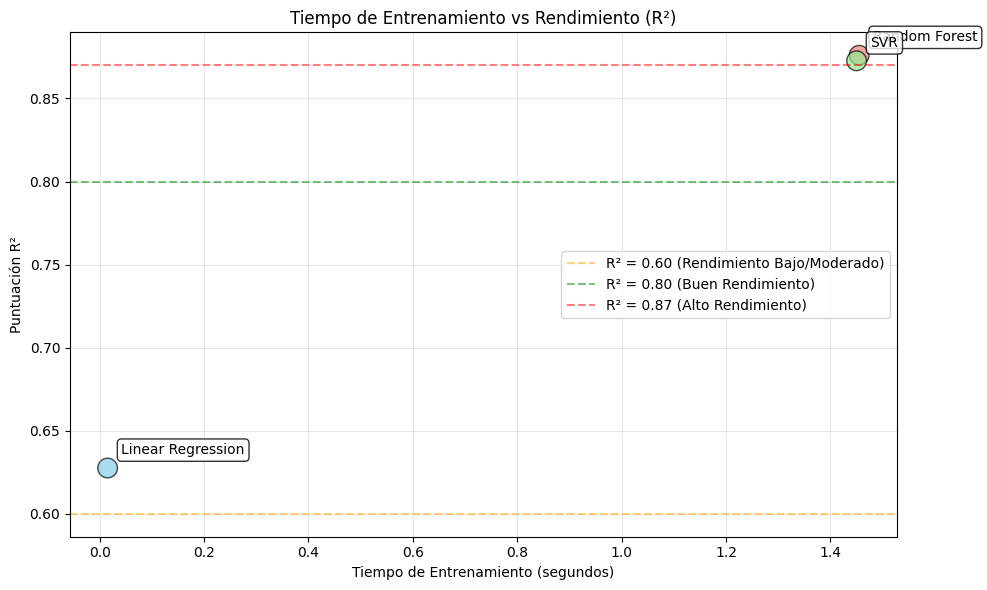


=== GRÁFICO COMPARATIVO DE PRECISIÓN (R²) ===



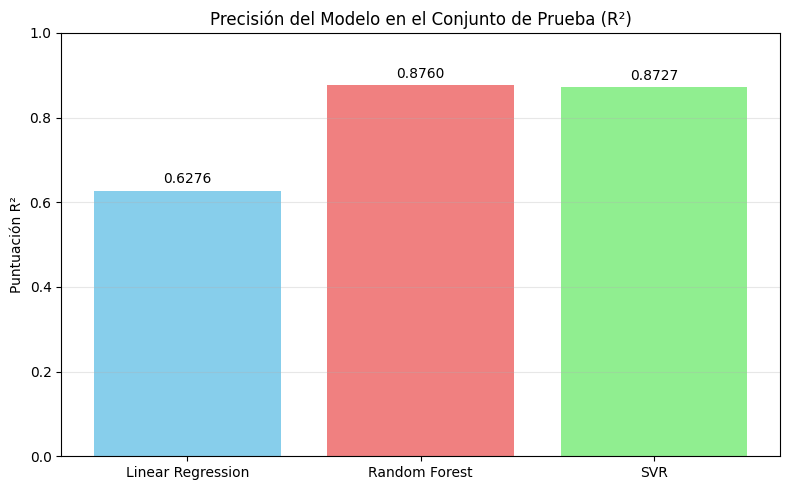

In [21]:
# Training Time vs. Performance Visualization and Accuracy Bar Plot

# Get model names
model_names = list(regression_models.keys())

# --- Training Time vs. Performance Scatter Plot ---

# Define colors for points (you can adjust this list)
colors = ['skyblue', 'lightcoral', 'lightgreen']

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Extract data
times = [training_durations[model] for model in model_names]
r2_scores = [results_test[model]['R²'] for model in model_names]

# Scatter plot
scatter = ax.scatter(times, r2_scores, c=colors, s=200, alpha=0.7, edgecolors='black')

# Add model labels
for i, model in enumerate(model_names):
    ax.annotate(model, (times[i], r2_scores[i]),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

ax.set_xlabel('Tiempo de Entrenamiento (segundos)')
ax.set_ylabel('Puntuación R²')
ax.set_title('Tiempo de Entrenamiento vs Rendimiento (R²)')
ax.grid(True, alpha=0.3)

# Add reference lines (adjust values if necessary for your context)
ax.axhline(y=0.60, color='orange', linestyle='--', alpha=0.5, label='R² = 0.60 (Rendimiento Bajo/Moderado)')
ax.axhline(y=0.80, color='green', linestyle='--', alpha=0.5, label='R² = 0.80 (Buen Rendimiento)')
ax.axhline(y=0.87, color='red', linestyle='--', alpha=0.5, label='R² = 0.87 (Alto Rendimiento)')

ax.legend()

plt.tight_layout()
plt.show()


# --- Comparative Bar Plot of Accuracy (R²) ---
print("\n=== GRÁFICO COMPARATIVO DE PRECISIÓN (R²) ===")
print()

# Extract R² scores from the test set for the bar plot
r2_test_scores = [results_test[model]['R²'] for model in model_names]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, r2_test_scores, color=['skyblue', 'lightcoral', 'lightgreen']) # Use same colors for consistency

plt.ylabel('Puntuación R²')
plt.title('Precisión del Modelo en el Conjunto de Prueba (R²)')
plt.ylim(0, 1) # R² is typically between 0 and 1

# Add R² values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Preguntas sobre algoritmos de Regresión

## 1. ¿Qué supuestos importantes debe cumplir `LinearRegression` sobre la relación entre las variables independientes y la variable dependiente? ¿Qué pasa si estos supuestos no se cumplen?

La Regresión Lineal asume varios puntos clave sobre tus datos para funcionar correctamente:

- **Linealidad:** La relación entre cada variable de entrada y la variable objetivo debe ser lineal.
- **Independencia de los errores:** Los errores de predicción deben ser independientes entre sí.
- **Homoscedasticidad:** La dispersión de los errores debe ser constante en todos los niveles de predicción.
- **Normalidad de los errores:** Los errores deben seguir una distribución normal.

**Consecuencias si no se cumplen:**
- Las estimaciones de los coeficientes pueden ser incorrectas.
- Las pruebas estadísticas y los intervalos de confianza pueden no ser válidos.
- La precisión de las predicciones puede disminuir.

En resumen, violar estos supuestos debilita la fiabilidad y validez de los resultados de la regresión lineal.

---

## 2. Compara la flexibilidad de `RandomForest` versus `LinearRegression`. ¿Cuál puede capturar mejor las relaciones no lineales complejas y por qué?

**Regresión Lineal:**  
Modelo rígido que solo captura relaciones lineales (líneas rectas). Flexibilidad baja.

**Random Forest:**  
Modelo basado en árboles de decisión que divide el espacio de datos en regiones. Al promediar muchos árboles:
- Se adapta mejor a patrones no lineales complejos.
- Puede capturar relaciones más allá de una simple línea recta.
- Ajusta mejor a la forma real de los datos.

**Resultados:**  
Random Forest tuvo un **R² mucho mayor (0.8760)** que la Regresión Lineal (0.6276), lo que indica que capturó mejor las relaciones no lineales presentes.

---

## 3. Entre `LinearRegression` y `SVR`, ¿cuál es más robusto ante valores atípicos (outliers)? Explica el motivo.

**Regresión Lineal:**  
Sensible a valores atípicos porque minimiza la suma de los errores al cuadrado. Los outliers influyen de manera desproporcionada en el ajuste.

**Support Vector Regression (SVR):**  
Más robusto ante outliers. Utiliza función de pérdida epsilon-insensible que:
- Ignora errores pequeños.
- Penaliza menos los errores grandes.
- Reduce la influencia de valores extremos en el modelo.

Por esto, SVR es más robusto frente a outliers que la Regresión Lineal.

---

## 4. En `RandomForest` para regresión, ¿qué efecto tendría aumentar significativamente el parámetro `n_estimators` (número de árboles) en el rendimiento y tiempo de entrenamiento?

**Efectos principales:**

- **Rendimiento:**  
  - Mejora la precisión del modelo.
  - Reduce la varianza y el sobreajuste.
  - Las mejoras se vuelven marginales al agregar más árboles después de cierto punto.

- **Tiempo de Entrenamiento:**  
  - Aumenta casi linealmente con el número de árboles.
  - Cada árbol debe construirse y entrenarse, lo que incrementa el costo computacional.

**Ejemplo con n_estimators = 100:**
- Tiempo de entrenamiento ≈ 0.50 s.
- R² en el conjunto de prueba = 0.8760.

**Escenarios alternativos:**

- **n_estimators significativamente menor (10 árboles):**
  - Entrenamiento más rápido.
  - R² ligeramente menor a 0.8760.
  - Más riesgo de sobreajuste.

- **n_estimators significativamente mayor (500 o 1000 árboles):**
  - Entrenamiento más lento (5 a 10 veces más).
  - R² mejora marginal o se mantiene igual.
  - Ganancia mínima en reducción de varianza.

**Conclusión:**  
Aumentar `n_estimators` mejora la capacidad de generalización hasta cierto punto, pero incrementa el tiempo de entrenamiento. Es un compromiso entre precisión y eficiencia computacional.

---

## 5. Si necesitas explicar a un cliente no técnico qué factores influyen mas en las predicciones de tu modelo de regresion, ¿que algoritmo elegirías y como presentarias esta información?

**Algoritmo Seleccionado:** Optaría por la Regresión Lineal.

**- Motivo:** Es el modelo más fácil de interpretar. Asigna un coeficiente a cada variable, lo que permite ver de forma directa cómo influye en la predicción (si incrementa o reduce el valor y en qué magnitud). Modelos como Random Forest suelen ser más precisos, pero su interpretación es mucho más compleja.

**- Forma de Presentarlo:**

1. Emplear un lenguaje claro y accesible, evitando tecnicismos.
2. Explicar el efecto de cada variable usando sus coeficientes (si aporta en positivo o negativo y su peso relativo).
3. Mostrar gráficos simples, por ejemplo diagramas de dispersión, para ilustrar las relaciones.
4. Destacar conclusiones y recomendaciones útiles para el cliente.

**Conclusión:** La Regresión Lineal es la opción más adecuada cuando se busca explicar la influencia de las variables a un público no técnico, gracias a su transparencia y facilidad de comprensión, aun si no es el modelo con mayor precisión. Lo importante es presentar los resultados de forma clara y útil.
